In [1]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.optimize


In [2]:
plt.rcParams["figure.dpi"] = 150
plt.rcParams["text.usetex"] = True
plt.rcParams["font.size"] = 12


# matplotlib.rcParams['mathtext.fontset'] = 'stix'
# matplotlib.rcParams['font.family'] = 'Computer Modern'


plt.rcParams['font.family'] = 'serif' # or 'sans-serif' or 'monospace'
plt.rcParams['font.serif'] = 'cmr10'
plt.rcParams['font.sans-serif'] = 'cmss10'
plt.rcParams['font.monospace'] = 'cmtt10'
plt.rcParams["axes.formatter.use_mathtext"] = True # to fix the minus signs
%config InlineBackend.figure_format = 'retina'
#plt.rcParams['axes.grid'] = True

In [3]:
theta = np.deg2rad(np.array([10.2, 31.0, 40.5, 50.0, 59.9, 69.8, 77.0]))
theta_err = np.deg2rad(1.0 * np.ones(len(theta)))

hyp_OLD = np.array([17.9, 19.0, 20.1, 21.1, 23.6, 25.0, 26.5])

hyp = np.array([19.2, 20.3, 21.4, 22.4, 24.9, 26.3, 27.8])
hyp_err = np.array([1.0, 1.2, 1.3, 1.6, 2.0, 2.9, 4.4])

t_vals = [19.0, 19.3, 19.5, 18.9, 18.8]
t = np.mean(t_vals)
t_err = 0.5

n = np.sin(theta) / np.sqrt(1 - (t/hyp)**2)

n_err = np.sqrt(
    (theta_err * np.cos(theta) / np.sqrt(1 - (t/hyp)**2))**2
    + (t_err * t * np.sin(theta) / (hyp**2 * (1 - (t/hyp)**2)**(3/2)))**2
    + (hyp_err * t**2 * np.sin(theta) / (hyp**3 * (1 - (t/hyp)**2)**(3/2)))**2
)

print(n)
print(n_err)



[1.73733265 1.52053577 1.44001415 1.46629369 1.34850058 1.3651885
 1.34098117]
[9.64775921 0.75978718 0.37420947 0.29791742 0.16342092 0.17289352
 0.19241417]


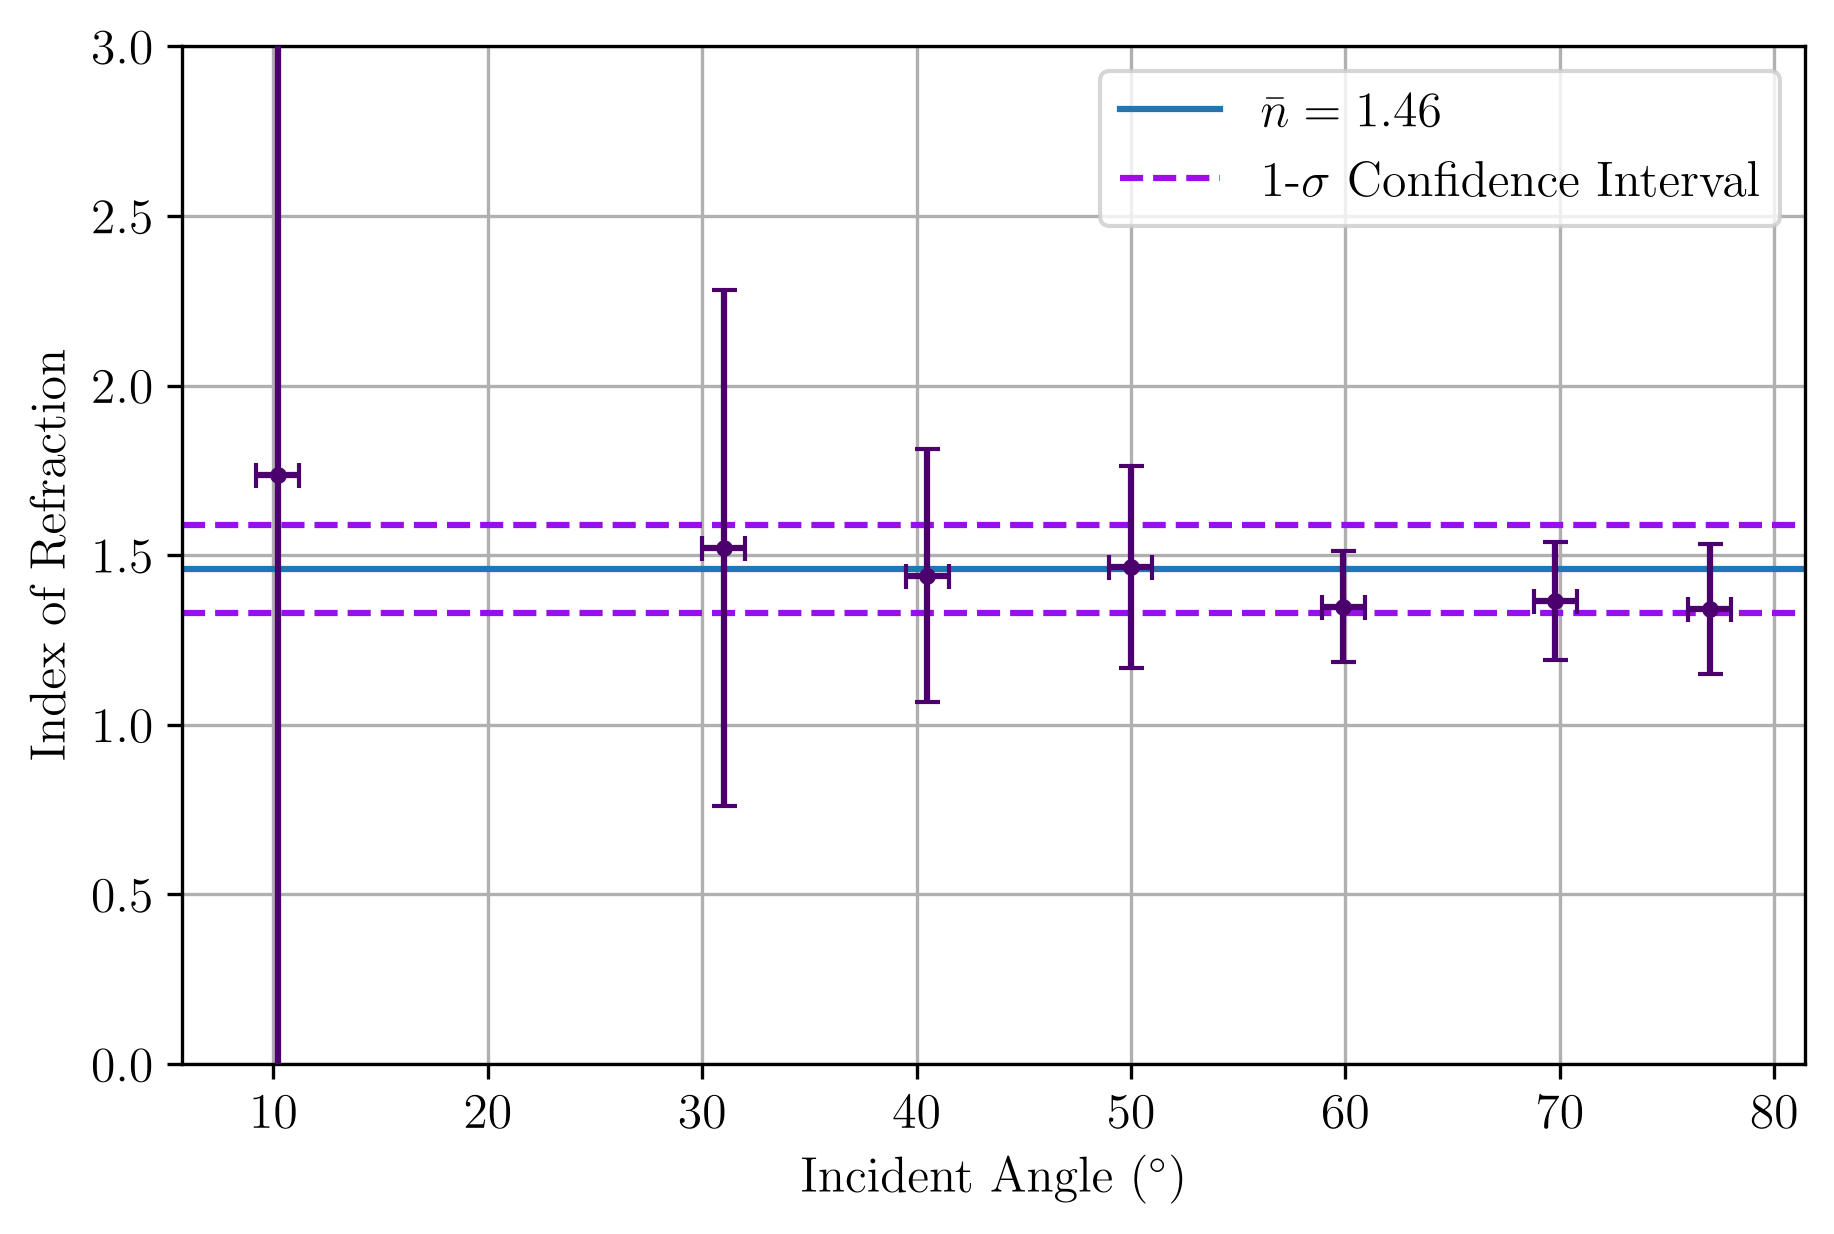

In [5]:
fig, ax = plt.subplots(figsize=(6, 4), layout="constrained")

ax.errorbar(np.rad2deg(theta), n, n_err, np.rad2deg(theta_err), fmt = 'o', markersize = 3, capsize = 3, color = 'xkcd:royal purple', zorder=10)

ax.axhline(np.mean(n), label=rf"$\bar{{n}} = {np.mean(n):0.2f}$")

ax.axhline(np.mean(n) - np.std(n), linestyle="dashed", color = "xkcd:violet")
ax.axhline(np.mean(n) + np.std(n), linestyle="dashed", color = "xkcd:violet", label=rf"1-$\sigma$ Confidence Interval")


ax.set_ylim(0, 3)

ax.set_title(r"")
ax.set_xlabel(r"Incident Angle $(^\circ)$")
ax.set_ylabel(r"Index of Refraction")
ax.grid()
ax.legend()

fig.savefig("exp4_plot.png", dpi=400)

